# Phase 2 -- Singular Value Decomposition (SVD) Analysis

## Objective

Reduce the dimensionality of the gene expression matrix using Truncated SVD. The original data has approximately 20,000 features (genes) per sample, which is computationally expensive and prone to noise. SVD identifies the directions of maximum variance in the data.

### Mathematical Formulation

For an input matrix X of shape (m x n), the SVD factorization is:

$$X \approx U \Sigma V^T$$

Where:
- **U** (m x k) -- left singular vectors representing sample coordinates in latent space
- **Sigma** (k x k) -- diagonal matrix of singular values indicating the importance of each component
- **V^T** (k x n) -- right singular vectors representing gene contributions to each component

We use Truncated SVD with k = 50 components, compressing the data from (801 x 20532) to (801 x 50).

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

import numpy as np
import pandas as pd

from src.data.load_data import load_uci_dataset
from src.linear_algebra.svd_core import compute_truncated_svd
from src.visualization.svd_plots import (
    plot_singular_values,
    plot_variance_explained
)


In [2]:
X = pd.read_csv(r"../Data/processed/X_processed.csv")
y = pd.read_csv(r"../Data/processed/labels.csv").iloc[:, 0]

X = X.values  # Convert to NumPy for speed

## 2.1 Compute Truncated SVD

We apply Truncated SVD with 50 components to the preprocessed gene expression matrix. The result is a low-dimensional representation U_reduced of shape (801 x 50) that captures the most significant patterns in the data.

In [3]:
U_reduced, singular_values, svd_model = compute_truncated_svd(
    X,
    n_components=50
)

print("Reduced representation shape:", U_reduced.shape)


Reduced representation shape: (801, 50)


## 2.2 Scree Plot -- Singular Value Spectrum

The scree plot displays the magnitude of each singular value in descending order. A sharp drop indicates that the first few components capture most of the variance, while the remaining components contribute diminishing amounts. This justifies using a low-rank approximation.

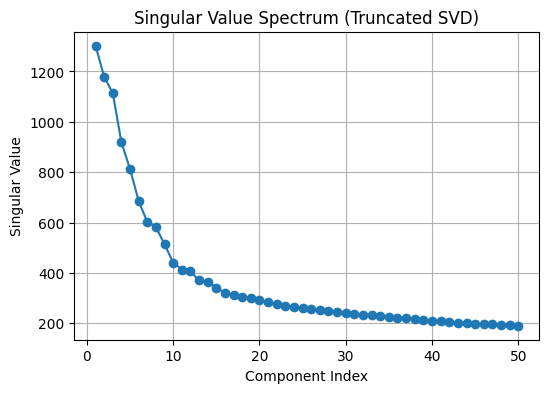

In [4]:
plot_singular_values(
    singular_values,
    save_path="../results/figures/svd_scree_plot.png"
)


## 2.3 Cumulative Variance Explained

This plot shows the fraction of total variance retained as we include more SVD components. A rapid rise followed by a plateau confirms that the gene expression data lies in a low-dimensional latent space -- a small number of components is sufficient to represent the essential structure.

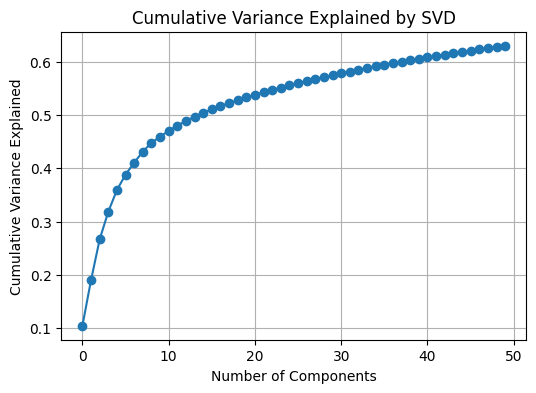

In [5]:
plot_variance_explained(
    svd_model,
    save_path="../results/figures/svd_variance_explained.png"
)


## 2.4 Variance Table

A tabular summary of each component's singular value and its individual explained variance ratio. This table is saved to `results/tables/variance_explained.csv` for reference.

In [6]:
variance_table = pd.DataFrame({
    "component": range(1, len(singular_values) + 1),
    "singular_value": singular_values,
    "explained_variance_ratio": svd_model.explained_variance_ratio_
})

variance_table.to_csv(
    "../results/tables/variance_explained.csv",
    index=False
)

variance_table.head()


,component,singular_value,explained_variance_ratio
0,1,1302.063643,0.104450
1,2,1178.782758,0.085607
2,3,1113.496047,0.076387
3,4,918.546485,0.051981
4,5,812.368950,0.040658
